In [1]:
# Plot an example ERF for poster

In [2]:
import os
import xarray as xr
import matplotlib.pyplot as plt
from utils.utils import autosize_figure

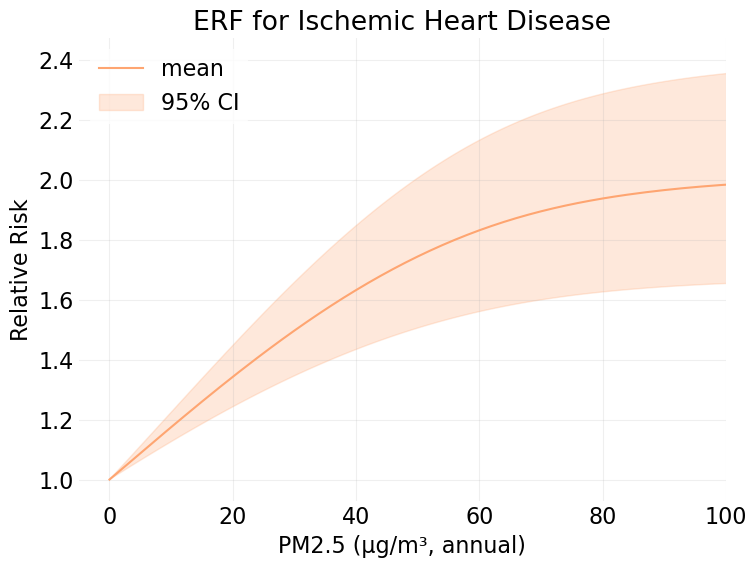

In [4]:
RR_DIR = "/glade/work/awells/air_quality/GBD21/RR_curves/"
SAVE_DIR = "/glade/u/home/awells/air_quality_project/plotting/example_workflow/"

health_VAR = "ISCHEMIC_HEART_DISEASE"

threshold = 4.15  # µg/m³ [2.4-5.9 UI]

color = "#FEA571"

RR_file = f"IHME_GBD_2021_AIR_POLLUTION_1990_2021_PM_RR_{health_VAR}.nc"
RR_path = os.path.join(RR_DIR, RR_file)
RR_list = xr.open_dataset(RR_path)

RR_mean = RR_list["mean"]  # mean
RR_lower = RR_list["lower"]  # lower bound
RR_upper = RR_list["upper"]  # upper bound

# Plot
fig, ax = plt.subplots(figsize=autosize_figure(1, 1))
plt.rcParams.update({'font.size': 16})
ax.plot(RR_list.exposure, RR_mean.data, color=color, label="mean")
ax.fill_between(RR_list.exposure, RR_lower.data, RR_upper.data, color=color, alpha=0.25, label="95% CI")

# Threshold lines
# ax.axvline(threshold, color="grey", linestyle=":", label="TMREL")
# ax.axvspan(threshold-1.75, threshold+1.75, color="lightgrey", alpha=0.3, label="95% CI")

plt.xlim(-5, 100)
plt.grid(True, alpha=0.2)

# Labels and title
ax.set_xlabel("PM2.5 (µg/m³, annual)")
ax.set_ylabel("Relative Risk")
ax.set_title("ERF for Ischemic Heart Disease")
plt.legend(
    frameon=True,
    facecolor="white",
    edgecolor="none",
    framealpha=0.8,
)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="x", length=0)
ax.tick_params(axis="y", length=0)

out_file = f"RR_{health_VAR}.png"
out_path = os.path.join(SAVE_DIR, out_file)
plt.savefig(out_path, dpi=300)